In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import kagglehub
import shutil
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
download_path = Path(kagglehub.dataset_download("laotse/credit-risk-dataset"))
cwd = Path.cwd()
dest = cwd / "credit_risk_dataset"
if dest.exists():
    shutil.rmtree(dest)
shutil.copytree(download_path, dest)

print(f"Dataset saved at: {dest}")

Dataset saved at: C:\Users\athar\OneDrive\Desktop\pandas notebook\credit_risk_dataset


In [3]:
df = pd.read_csv("credit_risk_dataset/credit_risk_dataset.csv")
print(df.head())
print(df.info())
print(df.shape)

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


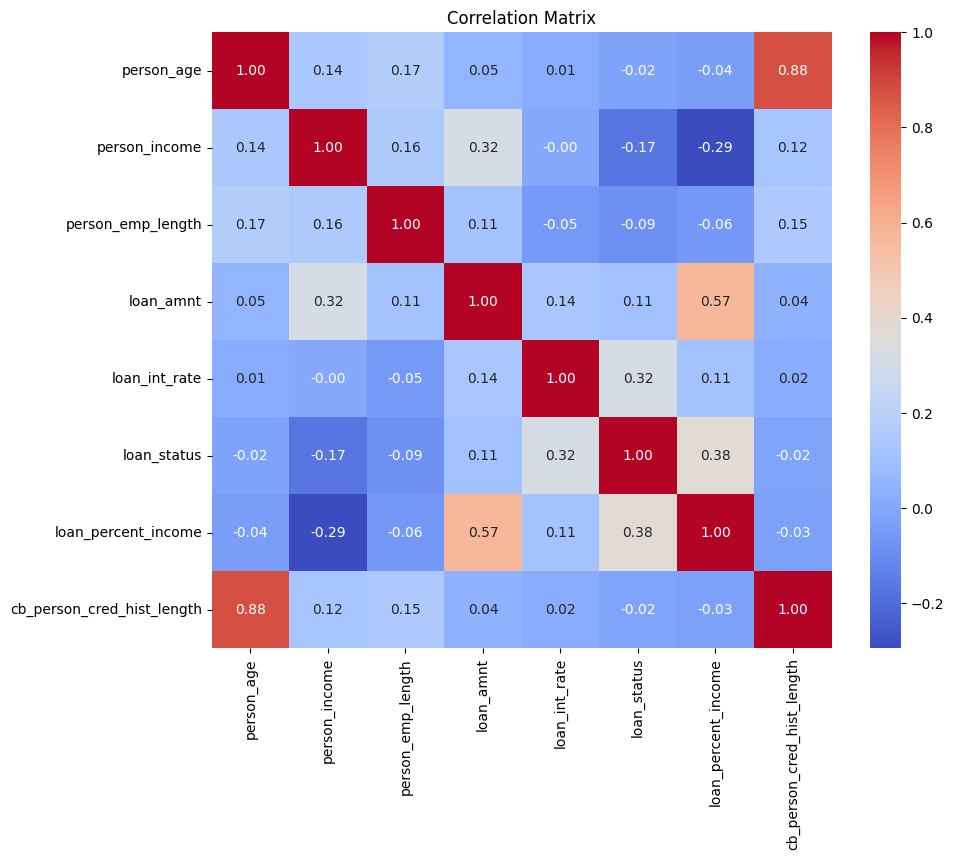

In [9]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In the next few cells I replaced the nan values with median because, they values are skewed.

I also removed unrealistic values such as age more than 100 and employement length more than 60.

In [4]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

<Axes: >

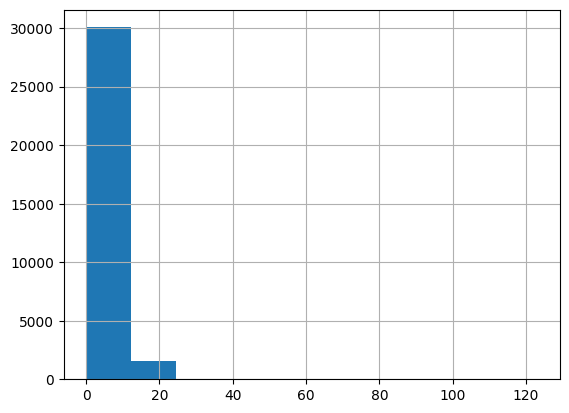

In [5]:
df["person_emp_length"].hist()

<Axes: >

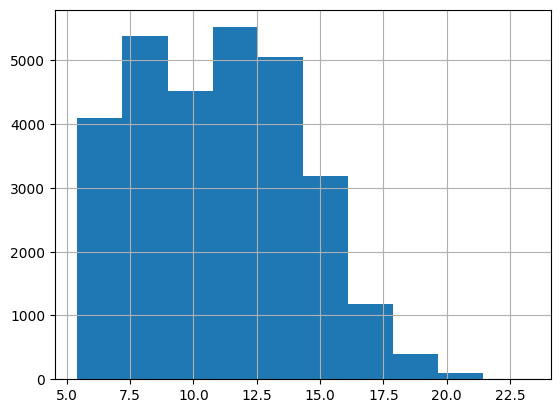

In [6]:
df["loan_int_rate"].hist()

In [7]:
df["person_emp_length"]=df["person_emp_length"].fillna(df["person_emp_length"].median())
df["loan_int_rate"]=df["loan_int_rate"].fillna(df["loan_int_rate"].median())
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [8]:
df.drop(df[(df["person_age"] > 100) | (df["person_emp_length"] > 60)].index, inplace=True)

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X=df.drop(["loan_status"],axis=1)
y=df["loan_status"]

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
X_train=scaler.fit_transform(X_train.drop(["person_home_ownership","loan_intent","loan_grade","cb_person_default_on_file"],axis=1))
X_test=scaler.transform(X_test.drop(["person_home_ownership","loan_intent","loan_grade","cb_person_default_on_file"],axis=1))

I used onehotencoder on the categorical values which were not heirarchial and used ordinal encoder on values which were heirarchial.

In [8]:
df.select_dtypes(include="object").head()

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y
5,OWN,VENTURE,A,N


In [12]:
print(df["loan_grade"].unique())
print(df["cb_person_default_on_file"].unique())

['B' 'C' 'A' 'D' 'E' 'F' 'G']
['N' 'Y']


In [13]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
ohe=OneHotEncoder(drop="first")
oe=OrdinalEncoder(categories=[['A', 'B', 'C', 'D', 'E', 'F', 'G'],['N','Y']])

In [14]:
X_train_obj=ohe.fit_transform(X_train[["person_home_ownership","loan_intent"]]).toarray()
X_test_obj=ohe.transform(X_test[["person_home_ownership","loan_intent"]]).toarray()

X_train_obj2=oe.fit_transform(X_train[["loan_grade","cb_person_default_on_file"]])
X_test_obj2=oe.transform(X_test[["loan_grade","cb_person_default_on_file"]])


In [17]:
X_train=np.hstack([X_train,X_train_obj,X_train_obj2])
X_test=np.hstack([X_test,X_test_obj,X_test_obj2])

In [18]:
X_test[0]

array([-0.4410825 ,  0.79788408, -1.1925746 , -0.41126157,  0.60319325,
       -0.94033719, -0.94109295,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        2.        ,  0.        ])

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

lreg=LogisticRegression()
dec_tree=DecisionTreeClassifier()
rand_forest=RandomForestClassifier()

In [20]:
lreg_grid=GridSearchCV(lreg,
                       param_grid={"C":[0.1,1,10]},
                       cv=5)
lreg_grid.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.1, 1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [21]:
dec_tree_grid=GridSearchCV(dec_tree,param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
},cv=5)
dec_tree_grid.fit(X_train,y_train)                    

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [22]:
rand_forest_grid=GridSearchCV(rand_forest,param_grid = {
    "n_estimators":[100,200],
    "max_depth":[3,5,10],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[2,4],
    "max_features":["sqrt"]
},cv=3)
rand_forest_grid.fit(X_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [2, 4], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [25]:
print(f"The best parameter in Logistic Regression is:{lreg_grid.best_params_}")
print(f"The best parameter in Decision Tree is:{dec_tree_grid.best_params_}")
print(f"The best parameter in Random Forest is:{rand_forest_grid.best_params_}")

The best parameter in Logistic Regression is:{'C': 10}
The best parameter in Decision Tree is:{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
The best parameter in Random Forest is:{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 100}


In [36]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix, roc_auc_score

In [27]:
y_pred_lreg=lreg_grid.predict(X_test)
y_pred_dec_tree=dec_tree_grid.predict(X_test)
y_pred_rand_forest=rand_forest_grid.predict(X_test)

In [38]:
print("Performance of LOGISTIC REGRESSION:")
print(f"Recall score is: {recall_score(y_test,y_pred_lreg)}")
print(f"Precision score is: {precision_score(y_test,y_pred_lreg)}")
print(f"Auc score is: {roc_auc_score(y_test, lreg_grid.predict_proba(X_test)[:,1])}")
print(f"Confusion matrix of this model is: {confusion_matrix(y_test,y_pred_lreg)}")

Performance of LOGISTIC REGRESSION:
Recall score is: 0.4929378531073446
Precision score is: 0.7173689619732785
Auc score is: 0.8662265393790518
Confusion matrix of this model is: [[4824  275]
 [ 718  698]]


In [44]:
print("Performance of DECISION TREE:")
print(f"Recall score is: {recall_score(y_test,y_pred_dec_tree)}")
print(f"Precision score is: {precision_score(y_test,y_pred_dec_tree)}")
print(f"Auc score is: {roc_auc_score(y_test, dec_tree_grid.predict_proba(X_test)[:,1])}")
print(f"Confusion matrix of this model is: {confusion_matrix(y_test,y_pred_dec_tree)}")

Performance of DECISION TREE:
Recall score is: 0.7189265536723164
Precision score is: 0.955868544600939
Auc score is: 0.9195322446076166
Confusion matrix of this model is: [[5052   47]
 [ 398 1018]]


In [45]:
print("Performance of RANDOM FOREST:")
print(f"Recall score is: {recall_score(y_test,y_pred_rand_forest)}")
print(f"Precision score is: {precision_score(y_test,y_pred_rand_forest)}")
print(f"Auc score is: {roc_auc_score(y_test, rand_forest_grid.predict_proba(X_test)[:,1])}")
print(f"Confusion matrix of this model is: {confusion_matrix(y_test,y_pred_rand_forest)}")

Performance of RANDOM FOREST:
Recall score is: 0.719632768361582
Precision score is: 0.9714013346043852
Auc score is: 0.92971494909271
Confusion matrix of this model is: [[5069   30]
 [ 397 1019]]


### When we compared all the models, Random Forest came out on top. It had the strongest overall performancewith an ROC-AUC of 0.93 and struck a solid balance between catching actual defaulters (recall around 0.72) and being precise when it flagged someone (precision around 0.97). In plain terms, it made very few mistakes on both sides: it rarely missed a defaulter and rarely falsely accused somene who would have paid back. That made it our most trustworthy option.

### Logistic Regression, on the other hand, struggled with recall—meaning it let quite a few defaulters slip through, which is exactly the kind of risk we want to avoid.

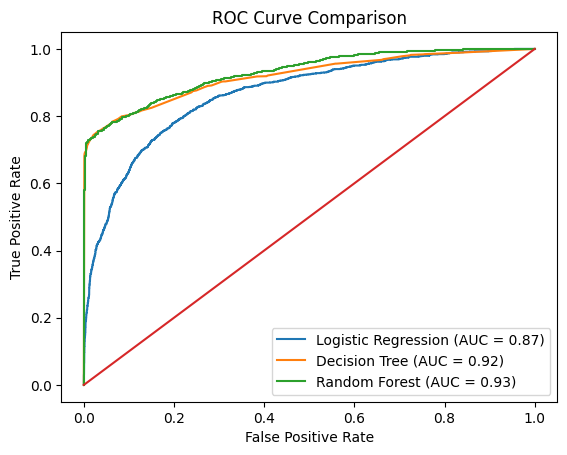

In [42]:
from sklearn.metrics import roc_curve

models = {
    "Logistic Regression": lreg_grid,
    "Decision Tree": dec_tree_grid,
    "Random Forest": rand_forest_grid
}

plt.figure()

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0,1], [0,1])  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

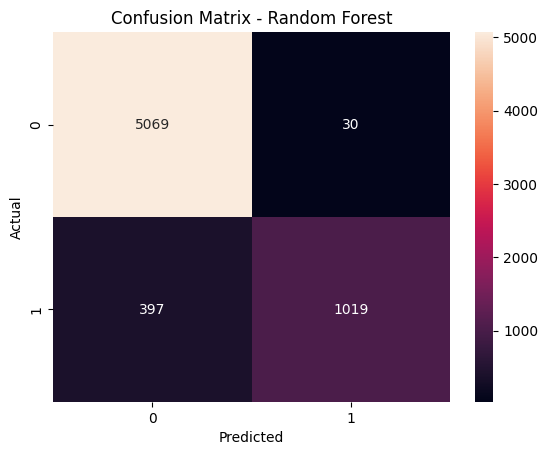

In [43]:
y_pred = rand_forest_grid.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()